In [ ]:
import numpy as np
import statsmodels.stats.api as sms

# Параметры эксперимента
p1 = 0.10  # Текущая конверсия
p2 = 0.12  # Ожидаемая конверсия
alpha = 0.05  # Уровень значимости
power = 0.80  # Мощность теста

# Расчет Effect Size
effect_size = sms.proportion_effectsize(p1, p2)

sample_size = sms.NormalIndPower().solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1.0
)

required_n = int(np.ceil(sample_size))
print(f"Необходимый размер выборки на одну группу: {required_n} пользователей")
print(f"Всего для теста (группа A + группа B): {required_n * 2} пользователей")

Необходимый размер выборки на одну группу: 3835 пользователей
Всего для теста (группа A + группа B): 7670 пользователей


In [ ]:
import pandas as pd

# Фиксируем генератор случайных чисел для воспроизводимости
np.random.seed(42)

# Генерация данных для группы
group_a_converted = np.random.binomial(n=1, p=0.10, size=required_n)
df_a = pd.DataFrame({
    'user_id': [f'user_A_{i}' for i in range(required_n)],
    'group': 'A',
    'converted': group_a_converted
})

# Генерация данных для группы
group_b_converted = np.random.binomial(n=1, p=0.118, size=required_n)
df_b = pd.DataFrame({
    'user_id': [f'user_B_{i}' for i in range(required_n)],
    'group': 'B',
    'converted': group_b_converted
})

# Объединяем данные в единый датасет
df_ab = pd.concat([df_a, df_b], ignore_index=True)

# Проверяем получившиеся базовые конверсии
ab_summary = df_ab.groupby('group')['converted'].agg(['count', 'sum', 'mean']).reset_index()
ab_summary.columns = ['Группа', 'Пользователи', 'Конверсий', 'CR (Conversion Rate)']
ab_summary['CR (Conversion Rate)'] = ab_summary['CR (Conversion Rate)'].map('{:.2%}'.format)

print(ab_summary)

  Группа  Пользователи  Конверсий CR (Conversion Rate)
0      A          3835        368                9.60%
1      B          3835        443               11.55%


In [4]:
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

# Количество успехов и общий размер выборок
conversions = np.array([df_a['converted'].sum(), df_b['converted'].sum()])
samples = np.array([len(df_a), len(df_b)])

# Z-тест
z_stat, p_value = proportions_ztest(count=conversions, nobs=samples)

# Рассчитываем относительный прирост
cr_a = df_a['converted'].mean()
cr_b = df_b['converted'].mean()
uplift = (cr_b - cr_a) / cr_a

print(f"Z-статистика: {z_stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Относительный прирост CR (Uplift): {uplift:.2%}")

# Вывод по гипотезе
alpha = 0.05
if p_value < alpha:
    print("\nРезультат: Статистически значимый, отклоняем нулевую гипотезу (H0).")
    print("Новый дизайн кнопки увеличивает конверсию.")
else:
    print("\nРезультат: Статистически значимых различий нет. Не можем отклонить H0.")

Z-статистика: -2.7850
p-value: 0.005354
Относительный прирост CR (Uplift): 20.38%

Результат: Статистически значимый, отклоняем нулевую гипотезу (H0).
Новый дизайн кнопки увеличивает конверсию.


/tmp/ipykernel_1493/2631143540.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_1493/2631143540.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


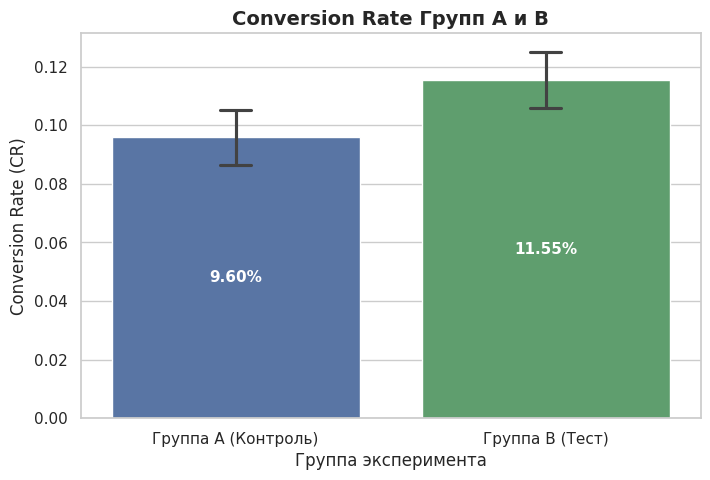

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Строим столбчатую диаграмму с доверительными интервалами (95%)
ax = sns.barplot(
    data=df_ab,
    x='group',
    y='converted',
    ci=95,
    palette=['#4C72B0', '#55A868'],
    capsize=0.1
)

plt.title('Conversion Rate Групп A и B', fontsize=14, fontweight='bold')
plt.xlabel('Группа эксперимента', fontsize=12)
plt.ylabel('Conversion Rate (CR)', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Группа A (Контроль)', 'Группа B (Тест)'])

# Подписываем значения над столбцами
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.2%}',
                    (p.get_x() + p.get_width() / 2., height / 2),
                    ha='center', va='center', fontsize=11, color='white', fontweight='bold')

plt.show()